# Spoken Language Processing - Instituto Superior Técnico
### Laboratory Assignment 2 - Automatic Age Estimation Challenge
<!--[image](imgs/lab2_slp_banner.png)-->
<img src="imgs/lab2_slp_banner.png" alt="drawing" width="400"/>

The second laboratory assignment of the course is designed to simulate an **age estimation challenge**. In this challenge, participants (a.k.a. students enrolled in the course) receive a training, development, and evaluation (blind) dataset, and a set of (weak) baseline systems for an introductory, easy task (gender classification) and for the final target task (age estimation).

The **goal** for each participant is to develop/build the best **age estimation system**. To this end, participants are first required to complete the lab Notebooks and then encouraged to incorporate other techniques and explore any approach that permits improving their results.


During the first week, students are expected to:
- Understand the main components of two simple baseline systems for gender classification (easy task): one based on **MFCC** features and **GMM** models and another based on **openSMILE** features and **SVM** models.
- Complete and run the main components of these baselines presented in the [`lab2_classical.ipynb`](https://gitlab.rnl.tecnico.ulisboa.pt/ist-slp/slp26/speech-processing-lab-2/) notebook.
- Propose, develop and explore simple modifications to the feature extraction pipeline.
- Propose, develop and explore simple modifications to the GMM and SVM model configurations.
- Adapt the openSMILE + SVM baseline to the age estimation task.


During the second week, students are expected to:
- Understand the main components of two modern sytems for age estimation: one based on speaker embeddings and the other on self-supervised learning features.
- Complete and run the main components of these systems presented in the  [`lab2_xvec.ipynb`](https://gitlab.rnl.tecnico.ulisboa.pt/ist-slp/slp26/speech-processing-lab-2/) and [`lab2_ssl.ipynb`](https://gitlab.rnl.tecnico.ulisboa.pt/ist-slp/slp26/speech-processing-lab-2/)  notebooks.
- Propose, develop and explore simple modifications, including testing different feature extractor versions and downstream regressors.
- Evaluate the models on the development partition.
- Propose, develop, extend, combine and/or modify the different systems to obtain the best possible age estimation system.
- Obtain predictions for the blind test partition and prepare the submission.


## About the data

The data consists of mono audio files sampled at 16 kHz, all of them containing speech spoken by native Portuguese speakers extracted from recording of the Assableia da República sessions.

The dataset is organized in 4 partitions:
- `'train'`: This is the full training set, consisting of 3239 audio samples of between 10 and 30-seconds each containg speech from 1121 different speakers. (**ATENTION**: Do not use this dataset for training your models, unless your system is very fast or if you want to build your final model).
- `'train_small'`: This is a subset of the full training set that consists of roughly one fifth of the full set (**RECOMMENDATION**: Use this partition in your quick experiments, to more rapidly validate alternatives)
- `'dev'`: This is the development set. It contains the same kind of segments as the training partitions. You will typically use this to validate the quality of your model.
- `'evl'`: This is the evaluation set. It contains the same kind of segments as the training partitions. You don't have the ground-truth for this set. You are expected to generate a prediction file and submit it.

The data used in this challenge is a subset of [FalAR: A Large-scale Speaker-Annotated European Portuguese Speech Corpus of Parliamentary Sessions](https://huggingface.co/datasets/inesc-id/FalAR). (**NOTE**: The train, dev and evl partitions are sourced from the corresponding original splits of FalAR. If you would like to use more data from FalAR, be sure to use only data from the training split to avoid data leakage/unrealistic results.)





## Before starting

We suggest to use [Visual Studio Code](https://code.visualstudio.com) with all the necessary extensions to run Jupyter notebooks. Alternatively, [Google Colab](https://colab.research.google.com) can also be used, but one needs to be carefull with potential data persistance issues.

In the case of running these notebooks in a local machine, we strongly recommend to create a new [virtual enviroment](https://code.visualstudio.com/docs/python/environments#_creating-environments) for this project. Python interpreter version should not be lower than **Python 3.9**.

The following conditions are necessary to run correctly this notebook:

*   All modules included in the `requirements.txt` file need to be 
installed in the Python environment. In a local installation, you can run in the command line: `pip install -r requirements.txt`
*   The module `pf_tools` needs to be accessible (if you are using Google Colab, you will need to copy the `pf_tools.py` every time you start a new session).

In [ ]:
from pf_tools import CheckThisCell

## How can you download (and process) the data

### Set-up the working and data directories
The first thing we have to do is to set our working directory. If you are using Google Colab, you probably want to mount Google Drive to keep persistent information, such as data, features and models. If you are not using Google Colab, you rather comment or delete the following code cell:

In [ ]:
# raise CheckThisCell ## <---- Remove this after completing/checking this cell
import os 

CWD = os.getcwd() # <--- Change this variable to your working directory. The default is the current directory
DATADIR = f'{CWD}/lab2_data/' # <--- Change this variable to your folder containig the LAB2 data
if not os.path.isdir(DATADIR):
    os.mkdir(DATADIR)

os.chdir(CWD)
print(f'Current working directory is set to {CWD}')   
print(f'Your LAB2 data folder is {DATADIR}')

Current working directory is set to c:\Users\dinis\OneDrive\Desktop\Processamento_da_fala\Lab_2
Your LAB2 data folder is c:\Users\dinis\OneDrive\Desktop\Processamento_da_fala\Lab_2/lab2_data/


### Use the `SLPdata` class to download and process challenge data

#### Data download 

The class `SLPdata` permits downloading, transforming and storing the different data partitions. Each `SLPdata` instance can be used to iterate over all the samples of the partition. It can also be used in combination with pytorch dataloader to read batches of data to train neural networks with pytorch. For instance, consider the following piece of code:


In [ ]:
import numpy as np
from pf_tools import SLPdata
import librosa 

def extract_raw_data(filename):
    y, _ = librosa.load(filename, sr=16000, mono=True, duration=None)
    return y.reshape(-1,1)
    
train_small = SLPdata(DATADIR, 'train_small', transform_id='raw', audio_transform=extract_raw_data)

100%|██████████| 387M/387M [03:55<00:00, 1.72MB/s] 
647it [01:06,  9.66it/s]



This code spinet first downloads and uncompresses the .tgz file containing all the necessary data of the selected   partition (`'train_small'`). The audio wav files are stored to disk (in DATADIR/train_small/wav/) and also a CSV file (DATADIR/train_small/info.csv). Have a look to the folder just created and its contents.

(Notice that the downloading of a specific dataset partition only happens the first time the SLPdata class is instantiated)

In [ ]:
!ls lab2_data/train_small

'ls' is not recognized as an internal or external command,
operable program or batch file.


You can plot the waveform and spectrogram of one of the audio files downloaded:

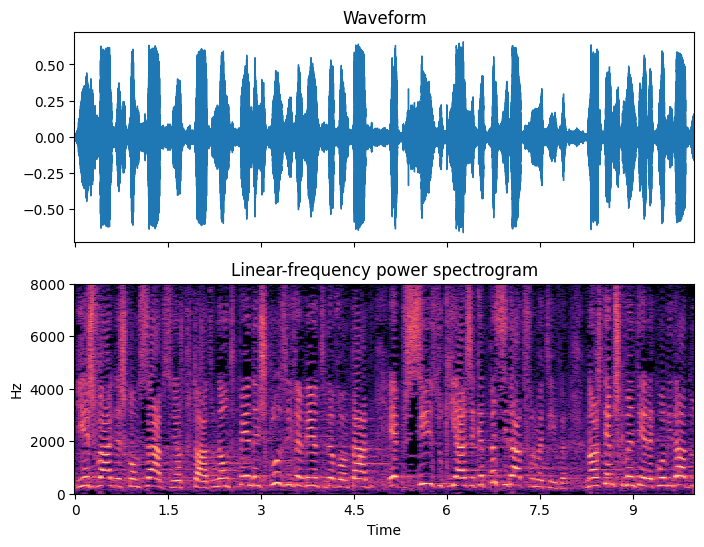

In [ ]:
from pf_tools import audioplot

%matplotlib inline
audiofile = f'{DATADIR}/train_small/wav/00834c0e904d40eda496e55010acebc5.wav'
audioplot(audiofile, sr=16000, mono=True, duration=10)


And listen to some examples: 

In [ ]:
import IPython.display as ipd
ipd.Audio(audiofile) # load a local WAV file

#### Audio file transformation

In addition to the parameter for selecting the dataset partition, the `SLPdata` class has a mandatory argument named `audio_transform` that corresponds to a callable (function) of a single  argument.  

**Audio transformations** receive a filename of an audio file, load the contents, apply some sort of transformation or **feature extraction**, and return an array of dimensions (NxD), in which N is the time dimension and D the dimension of the feature vector.  The resulting features are stored in disk in the folder indicated with the argument `transform_id`. 

In this particular case, the  audio transformation `'extract_raw_data'` simply loads the audio file and returns the raw audio data in an array of D=1. The result is stored to disk DATADIR/train_small/raw/. You can have a look to the contents of the folder.

(If the feature extraction process is interrupted, you will need to delete the corresponding tranformation folder to restart)

In [ ]:
!ls lab2_data/train_small/raw/

'ls' is not recognized as an internal or external command,
operable program or batch file.


**NOTE**  The `SLPdata` class has some additional parameters that permit uniformily segmenting the output of the audio transformation (with configurable size and stride), applying additional transformations to each segment and storing the result as individual feature files, that will be recovered when iterating over the `SLPdata` instance. Overall, the combination of audio and segment transformations permits quite flexible feature extraction pipeline that (hopefully) can match the needs of almost any training setting. In the remaing, for sake of simplicity, we will consider that for each audio file a single feature array/file is generated.

### Iterating data

As mentioned previously, once we have instanciated an SLPdata dataset, it can be iterated to have access to each data sample (including feature data, labels and identifier).

For instance, we can retrieve the first feature array as follows:

In [16]:
sample, label, basename = next(iter(train_small)) 

print(f'Sample shape: {sample.shape}')
print(f'Label class: {label}')
print(f'Identifier file: {basename}')

Sample shape: (388800, 1)
Label class: ('F', 59.0)
Identifier file: 00834c0e904d40eda496e55010acebc5


Or we can iterate the complete dataset:

In [17]:
import time
start = time.time()
for i, sample in enumerate(train_small):
    data, label, basename = sample # array, str, str
    if i % 25 == 0:
        print(i, data.shape, label, basename)

print(f'Finished reading all data in {time.time() - start}')

0 (388800, 1) ('F', 59.0) 00834c0e904d40eda496e55010acebc5
25 (452976, 1) ('F', 54.0) 0956c79e20cd410f97721dfb198c4d61
50 (329568, 1) ('M', 40.0) 1272812f1a2b4e17b746a6f72431652c
75 (302240, 1) ('M', 64.0) 1caf59ce67eb4b809d22d9c5ddf3d2fe
100 (294608, 1) ('F', 49.0) 25ca4c44814a4ce0a865308d55766314
125 (254736, 1) ('F', 51.0) 2d1613177ace411dac62603d91c19c2e
150 (312352, 1) ('M', 39.0) 39dcb09f0bd2429d898f8e847d0ad008
175 (300064, 1) ('F', 52.0) 450f8ff3edaa496cb1c043fea87ef9d8
200 (280672, 1) ('F', 53.0) 4b75e042e9bf432e9f0db735ef122633
225 (478624, 1) ('F', 52.0) 54d2fe8c754c43ed832e698ff37a03bc
250 (384704, 1) ('F', 47.0) 5fd4f4d6a5164b75a77c95d5080315c9
275 (473728, 1) ('M', 42.0) 68fdb7d6b4fa4c50a564c988c8480e33
300 (178560, 1) ('M', 54.0) 7344840801464fc9b231752a9a41ba7f
325 (369136, 1) ('F', 54.0) 7ab070bd0a634b8183067bf576eaca74
350 (284768, 1) ('F', 51.0) 851d7b7933f746bdab5831df11312c71
375 (414736, 1) ('M', 55.0) 8ea9e257052143a0bd5fce5644364c97
400 (437136, 1) ('F', 43.0) 9

Now you can use the `SLPdata` class to check the  number of files and size (in minutes) of the training set for each gender. You should keep these numbers to include in your system description paper:

In [23]:
# Inspect the training data to find the size of each training language
# raise CheckThisCell ## <---- Remove this after completeing/checking this cell

GENDER_CLASSES = ('F',  'M')    
train = SLPdata(DATADIR, 'train_small', transform_id='raw', audio_transform=extract_raw_data)
# train = SLPdata(DATADIR, 'train', transform_id='raw', audio_transform=extract_raw_data)

nfiles_per_gender = dict().fromkeys(GENDER_CLASSES, 0)
nsamples_per_gender = dict().fromkeys(GENDER_CLASSES, 0)

# <----- LAB WORK: ADD YOUR CODE HERE THAT COUNTS THE NUMBER OF FILES AND SAMPLES PER GENDER
# TIP: Iterate over the train_small object and update the num_files and num_samples dictionaries.
#      Notice that the label of each sammple is a tuple with gender (str) and age (int)
for i, sample in enumerate(train):
    data,label,basename=sample
    gender = label[0]  # Extract gender from the label tuple
    nfiles_per_gender[gender] += 1
    nsamples_per_gender[gender] += len(data)

sampling_rate = 16000
for gender in GENDER_CLASSES:
    print(f'{gender}:\t{nfiles_per_gender[gender]}\t{nsamples_per_gender[gender]/(60*sampling_rate):.2f} minutes')

# The expected output should be something like for the train_small:
# F:	321	116.26 minutes
# M:	326	122.36 minutes
#
# And the following for train:
# F:	1631	601.81 minutes
# M:	1607	611.18 minutes

c:\Users\dinis\OneDrive\Desktop\Processamento_da_fala\Lab_2\pf_tools.py:108: UserWarning: The feature directory already exists, and no new feature extraction will be performed.
  warnings.warn("The feature directory already exists, and no new feature extraction will be performed.")


F:	321	116.26 minutes
M:	326	122.36 minutes


You can adapt the previous code to obtain an histogram of the number of files per age in the training set:

c:\Users\dinis\OneDrive\Desktop\Processamento_da_fala\Lab_2\pf_tools.py:108: UserWarning: The feature directory already exists, and no new feature extraction will be performed.
  warnings.warn("The feature directory already exists, and no new feature extraction will be performed.")


Text(0, 0.5, 'Minutes')

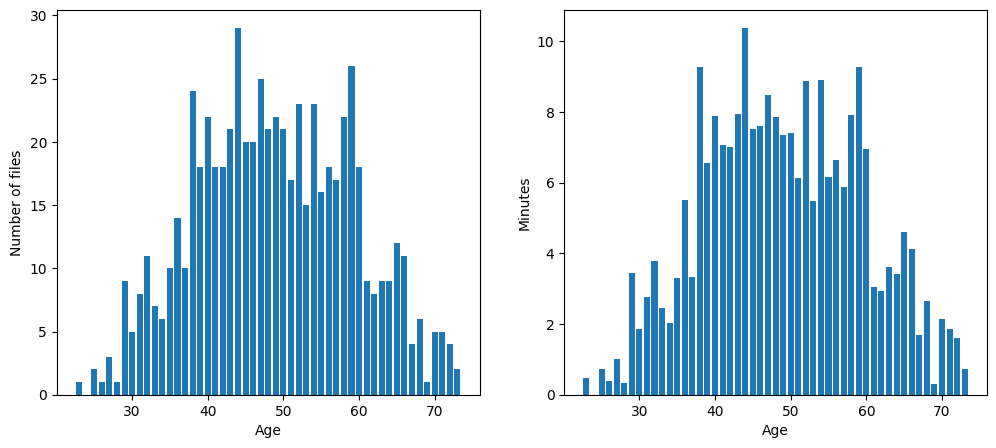

In [24]:
import matplotlib.pyplot as plt

train = SLPdata(DATADIR, 'train_small', transform_id='raw', audio_transform=extract_raw_data)
# train = SLPdata(DATADIR, 'train', transform_id='raw', audio_transform=extract_raw_data)

nfiles_per_age = {}
nsamples_per_age = {}
sampling_rate = 16000

# <----- LAB WORK: ADD YOUR CODE HERE THAT COUNTS THE NUMBER OF FILES AND SAMPLES PER AGE
# TIP: Iterate over the train_small object and update the num_files and num_samples dictionaries.
#      Notice that the label of each sammple is a tuple with gender (str) and age (int)
for i, sample in enumerate(train):
    data,label,basename=sample
    age = label[1]
    if age not in nfiles_per_age:
        nfiles_per_age[age] = 0
        nsamples_per_age[age] = 0
    nfiles_per_age[age] += 1
    nsamples_per_age[age] += data.shape[0]

# Code that plots an histogram of the number of files per age and 
# a histogram of the number of minutes per age
ages = sorted(nfiles_per_age.keys())
nfiles = [nfiles_per_age[age] for age in ages]
nsamples = [nsamples_per_age[age] for age in ages]
minutes = [nsamples[i]/(60*sampling_rate) for i in range(len(ages))]
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.bar(ages, nfiles)
plt.xlabel('Age')
plt.ylabel('Number of files')
plt.subplot(1,2,2)
plt.bar(ages, minutes)
plt.xlabel('Age')
plt.ylabel('Minutes')


### Processing data in batches

Most common neural network learning recipes process data in batches of several data samples. 
For this purpose, the `SLPdata` class extends the `torch.utils.data.Dataset` and it can be used in combination with a Pytorch DataLoader to read data in batches. 

To build batches, the dimension of the samples of one batch need to be same. 
For exemplification purposes, we will change the `'extract_raw_data'` function to receive an additional parameter with duration to be extracted:  

In [29]:
def extract_raw_data(filename, duration=None):
    y, _ = librosa.load(filename, sr=16000, mono=True, duration=duration)
    return y.reshape(-1,1)

Now, we instantiate the `SLPdata` setting the duration of the raw data samples to 10 seconds. 

In [30]:
train_small_10= SLPdata(DATADIR, 'train_small', 
                     transform_id='raw10', 
                     audio_transform=lambda x: extract_raw_data(x, duration=10))

c:\Users\dinis\OneDrive\Desktop\Processamento_da_fala\Lab_2\pf_tools.py:108: UserWarning: The feature directory already exists, and no new feature extraction will be performed.
  warnings.warn("The feature directory already exists, and no new feature extraction will be performed.")


And we create the data loader and iterate to obtain batches of training samples:

In [31]:
import torch 

# Create data loader
train_batches = torch.utils.data.DataLoader(
        dataset=train_small_10,
        batch_size=8,
        shuffle=True
)

# Read data in batches
start = time.time()
for i, batch in enumerate(train_batches):
    data, label, basename = batch
    print('batch', i, data.shape, len(label), len(basename))

print(f'Finished reading all data in {time.time() - start}')

batch 0 torch.Size([8, 160000, 1]) 2 8
batch 1 torch.Size([8, 160000, 1]) 2 8
batch 2 torch.Size([8, 160000, 1]) 2 8
batch 3 torch.Size([8, 160000, 1]) 2 8
batch 4 torch.Size([8, 160000, 1]) 2 8
batch 5 torch.Size([8, 160000, 1]) 2 8
batch 6 torch.Size([8, 160000, 1]) 2 8
batch 7 torch.Size([8, 160000, 1]) 2 8
batch 8 torch.Size([8, 160000, 1]) 2 8
batch 9 torch.Size([8, 160000, 1]) 2 8
batch 10 torch.Size([8, 160000, 1]) 2 8
batch 11 torch.Size([8, 160000, 1]) 2 8
batch 12 torch.Size([8, 160000, 1]) 2 8
batch 13 torch.Size([8, 160000, 1]) 2 8
batch 14 torch.Size([8, 160000, 1]) 2 8
batch 15 torch.Size([8, 160000, 1]) 2 8
batch 16 torch.Size([8, 160000, 1]) 2 8
batch 17 torch.Size([8, 160000, 1]) 2 8
batch 18 torch.Size([8, 160000, 1]) 2 8
batch 19 torch.Size([8, 160000, 1]) 2 8
batch 20 torch.Size([8, 160000, 1]) 2 8
batch 21 torch.Size([8, 160000, 1]) 2 8
batch 22 torch.Size([8, 160000, 1]) 2 8
batch 23 torch.Size([8, 160000, 1]) 2 8
batch 24 torch.Size([8, 160000, 1]) 2 8
batch 25 t

### Cleaning up

Before starting Part 1 of this lab assignment:
* You should delete the folders containing the dummy features that you just generated (_'raw'_, _'raw10'_) from the two train data partitions.
* You can also delete the _.tgz_ files if you need to save space.

# What should you deliver at the end of this lab assignment?
You should deliver the following three elements:
- You must submit (via [Kaggle](https://www.kaggle.com/competitions/ist-slp-26-age-estimation-challenge) and Fênix) at least one prediction file in the format that will be described in the Notebook of part1.
- You must submit (via Fênix) all the modified notebooks (intro, classical, ssl and xvec) and any additional code used for your proposed system(s).
- You must submit a report (via Fênix) of maximum 2 pages describing your work, your system(s), approaches explored (may be unsuccesful), parameters explored, lessons learnt, results on the dev partition, etc. You can use the following Overleaf template for the report: [report](https://www.overleaf.com/latex/templates/interspeech-2023-paper-kit/kzcdqdmkqvbr)


# Contacts and support
You can contact the professors during the classes or the office hours.

Particularly, for this second laboratory assignment, you should contact Prof. Alberto Abad: alberto.abad@tecnico.ulisboa.pt



